# PCA Analysis of Data Science Salaries
Group 2, Prince Newman

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


Data Preparation

In [2]:
# Standardize ML Engineer job title
df['job_title'] = df['job_title'].replace({'ML Engineer': 'Machine Learning Engineer'})

# Select relevant columns
clean = df[['job_title', 'work_year', 'salary', 'salary_in_usd', 'salary_currency']].copy()

# Filter to USD, CAD, GBP currencies only
clean = clean.loc[
    clean['salary_currency'].isin(['USD', 'CAD', 'GBP'])
].copy()

# Drop duplicate job titles
clean = clean.drop_duplicates(subset=['job_title']).reset_index(drop=True)

# Set job_title as index and keep only numeric variables for PCA
clean_pca = clean.set_index('job_title')[['work_year', 'salary', 'salary_in_usd']]

print(f"Shape: {clean_pca.shape}")
print(f"\nVariables included: {list(clean_pca.columns)}")
print(f"\nDescriptive statistics:")
clean_pca.describe()

Shape: (86, 3)

Variables included: ['work_year', 'salary', 'salary_in_usd']

Descriptive statistics:


,work_year,salary,salary_in_usd
count,86.000000,86.000000,86.000000
mean,2021.395349,138480.406977,138721.511628
std,1.009124,99903.173571,99174.426233
min,2020.000000,8000.000000,8000.000000
25%,2021.000000,70000.000000,70000.000000
50%,2021.000000,121250.000000,116052.000000
75%,2022.000000,188500.000000,188500.000000
max,2023.000000,450000.000000,450000.000000


## Part 1

### Question 1: Can PCA reveal meaningful structure among data science job roles based on salary, salary in USD, and work year?
This is useful because most variables in our dataset are categorical. These three numeric variables are the only ones suitable for PCA. Understanding how job titles cluster in principal component space tells us whether compensation patterns alone can distinguish roles, and whether work year adds independent information beyond salary.

### Question 2: Variables and Standardization
Variables:
 - work_year: numeric, not salary-related, may capture time trends
 - salary: raw salary in local currency (USD/CAD/GBP)
 - salary_in_usd: salary converted to USD for comparability

Standardization will be done because salary values are in the hundreds of thousands while work_year is around 2020-2023. Without standardization, salary would dominate all components.

In [3]:
# standardize
scaler = StandardScaler(with_mean=True, with_std=True)
X = scaler.fit_transform(clean_pca)
X_df = pd.DataFrame(X, index=clean_pca.index, columns=clean_pca.columns)

print("After standardization (mean ~0, std ~1):")
X_df.describe().round(3)

After standardization (mean ~0, std ~1):


,work_year,salary,salary_in_usd
count,86.000,86.000,86.000
mean,0.000,0.000,0.000
std,1.006,1.006,1.006
min,-1.391,-1.314,-1.326
25%,-0.394,-0.689,-0.697
50%,-0.394,-0.173,-0.230
75%,0.603,0.504,0.505
max,1.599,3.137,3.157


### Question 3: Biplot

In [4]:
pcaDS = PCA()
pcaDS.fit(X)
scores = pcaDS.transform(X)

print("PCA Components (loadings):")
print(pd.DataFrame(
    pcaDS.components_.T,
    index=clean_pca.columns,
    columns=[f'PC{i+1}' for i in range(3)]
).round(4))

print(f"\nExplained variance ratio: {pcaDS.explained_variance_ratio_}")

PCA Components (loadings):
                  PC1     PC2     PC3
work_year     -0.0029  1.0000  0.0080
salary         0.7071 -0.0036  0.7071
salary_in_usd  0.7071  0.0077 -0.7071

Explained variance ratio: [0.66549366 0.33335163 0.00115471]


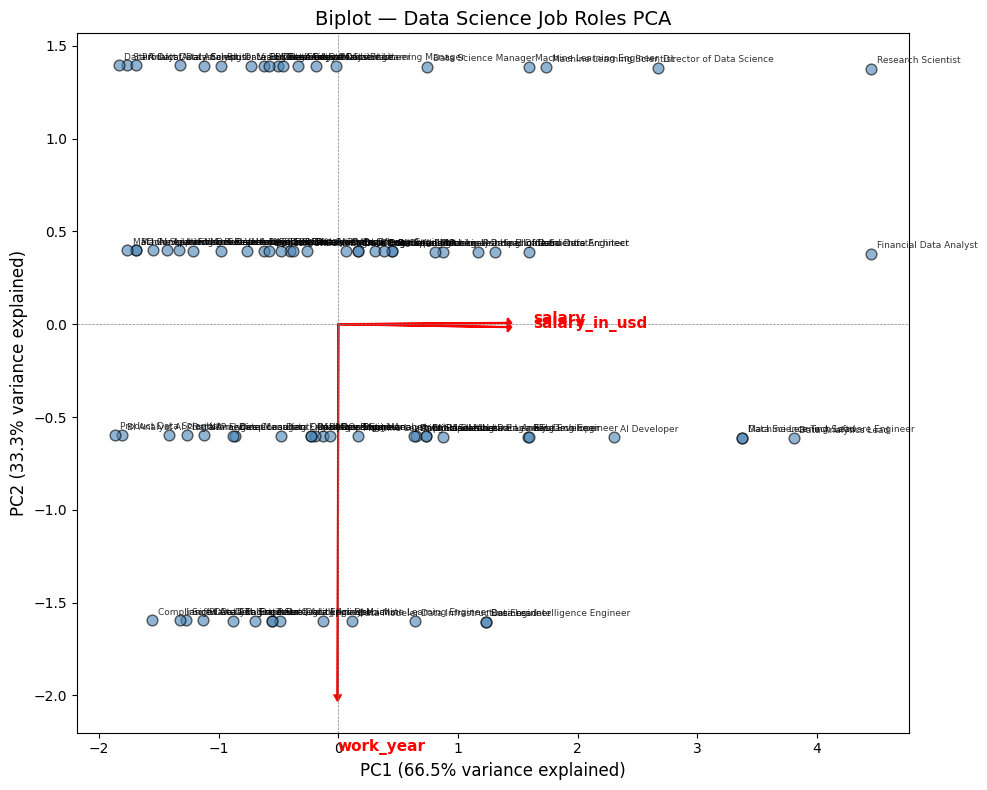

In [7]:
i, j = 0, 1
scale_arrow = 2

scores[:, 1] *= -1
pcaDS.components_[1] *= -1

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.scatter(scores[:, 0], scores[:, 1], alpha=0.6,
           color='steelblue', edgecolors='black', s=60)

# Label each job title point
for idx, label in enumerate(clean_pca.index):
    ax.annotate(label,
                (scores[idx, 0], scores[idx, 1]),
                fontsize=6.5, alpha=0.8,
                xytext=(4, 4), textcoords='offset points')

# Loading vectors
for k in range(pcaDS.components_.shape[1]):
    ax.arrow(0, 0,
             scale_arrow * pcaDS.components_[i, k],
             scale_arrow * pcaDS.components_[j, k],
             head_width=0.05, head_length=0.03,
             fc='red', ec='red', linewidth=1.5)
    ax.text(scale_arrow * pcaDS.components_[i, k] * 1.15,
            scale_arrow * pcaDS.components_[j, k] * 1.15,
            clean_pca.columns[k],
            fontsize=11, color='red', fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({pcaDS.explained_variance_ratio_[0]*100:.1f}% variance explained)',
              fontsize=12)
ax.set_ylabel(f'PC2 ({pcaDS.explained_variance_ratio_[1]*100:.1f}% variance explained)',
              fontsize=12)
ax.set_title('Biplot — Data Science Job Roles PCA', fontsize=14)
plt.tight_layout()
plt.savefig('biplot.png', dpi=150, bbox_inches='tight')
plt.show()

The biplot shows two main patterns. First, salary and salary_in_usd point in the same direction along the horizontal axis, which makes sense because they measure the same thing in different currencies. Second, work_year points straight down on the vertical axis, completely separate from the salary arrows, meaning the year a job was recorded has nothing to do with the salary level. The job title dots cluster into horizontal bands based on work year, and within each band they spread left to right based on how high or low the salary is, with roles like Research Scientist and Financial Data Analyst sitting furthest to the right indicating higher pay while most other roles bunch together in the middle reflecting similar compensation ranges.

### Question 4: Scree Plot

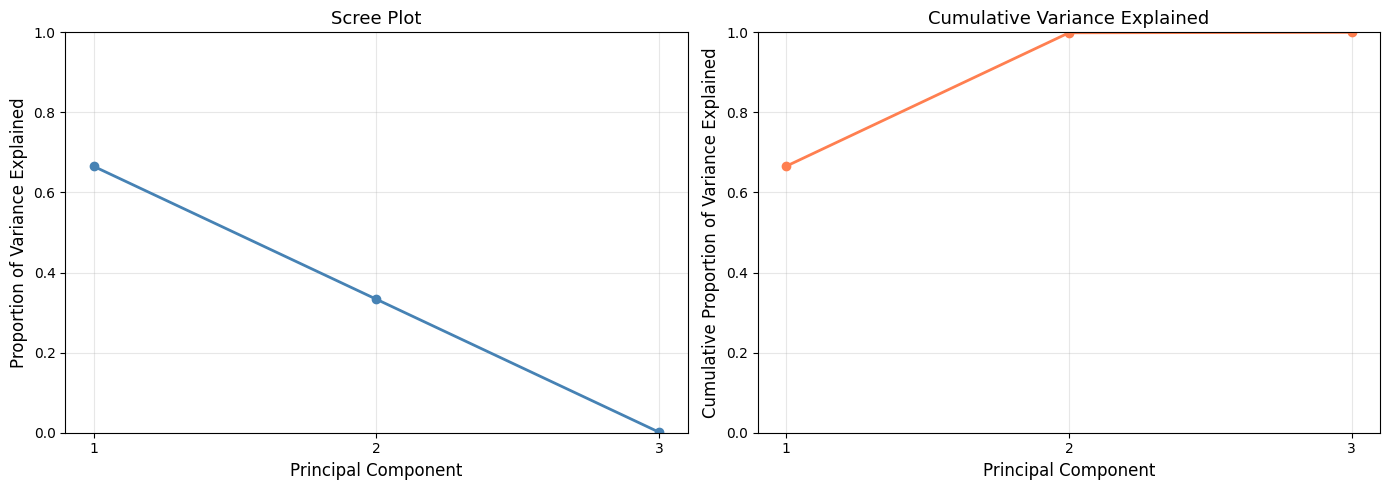

PC1 explains: 66.5%
PC2 explains: 33.3%
PC1+PC2 combined: 99.9%


In [8]:
ticks = np.arange(pcaDS.n_components_) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
ax = axes[0]
ax.plot(ticks, pcaDS.explained_variance_ratio_,
        marker='o', color='steelblue', linewidth=2)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Proportion of Variance Explained', fontsize=12)
ax.set_title('Scree Plot', fontsize=13)
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
ax.grid(alpha=0.3)

# Cumulative variance
ax = axes[1]
ax.plot(ticks, pcaDS.explained_variance_ratio_.cumsum(),
        marker='o', color='coral', linewidth=2)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Cumulative Proportion of Variance Explained', fontsize=12)
ax.set_title('Cumulative Variance Explained', fontsize=13)
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"PC1 explains: {pcaDS.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pcaDS.explained_variance_ratio_[1]*100:.1f}%")
print(f"PC1+PC2 combined: {pcaDS.explained_variance_ratio_[:2].sum()*100:.1f}%")

The scree plot shows that PC1 explains about 66.5% of the variation in the data and PC2 explains about 33.3%, and together they account for nearly 100% of all the variation. PC3 contributes almost nothing at just 0.1% and can be safely ignored. The cumulative plot on the right confirms this clearly, showing the line reaches 100% by PC2. This means the first two principal components are more than sufficient for visualization in the biplot and nothing meaningful is lost by stopping there. The reason all variation is captured in just two components is that our three variables essentially behave as two independent pieces of information, salary and salary_in_usd move together as one, and work_year acts entirely on its own.

## PART 2: PCA-Based Imputation with Missing Values

Create missing values, In internationally sourced salary datasets, salary values in local currency are sometimes missing when the data was collected from job postings that only listed USD equivalents. We simulate this by randomly removing 20 values across the dataset.

In [9]:
np.random.seed(15)
n_omit = 20

r_idx = np.random.choice(np.arange(X.shape[0]), n_omit, replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]), n_omit, replace=True)

Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

print(f"Total missing values created: {n_omit}")
print(f"Percentage missing: {n_omit / X.size * 100:.1f}%")
print(f"Missing per column:")
print(pd.DataFrame(np.isnan(Xna), columns=clean_pca.columns).sum())

Total missing values created: 20
Percentage missing: 7.8%
Missing per column:
work_year        9
salary           3
salary_in_usd    8
dtype: int64


In [10]:
# SVD low-rank imputation

def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X)
    L = U[:, :M] * D[None, :M]
    return L.dot(V[:M])

def pca_impute(Xna, X_true, M=1, thresh=1e-7):
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xhat, axis=0)
    ismiss = np.isnan(Xna)

    # Initialize missing with column means
    Xhat[ismiss] = Xbar[c_idx]

    rel_err = 1
    count = 0
    mssold = np.mean(Xhat[~ismiss]**2)
    mss0 = np.mean(Xna[~ismiss]**2)

    while rel_err > thresh:
        count += 1
        Xapp = low_rank(Xhat, M=M)
        Xhat[ismiss] = Xapp[ismiss]
        mss = np.mean(((Xna - Xapp)[~ismiss])**2)
        rel_err = abs(mssold - mss) / mss0
        mssold = mss

    corr = np.corrcoef(Xapp[ismiss], X_true[ismiss])[0, 1]
    return Xapp, corr, count

In [11]:
# Compare different values of M
M_values = [1, 2, 3]
correlations = {}

print(f"{'M':>4} | {'Correlation':>12} | {'Iterations':>10} | Interpretation")
print("-" * 60)

for M in M_values:
    Xapp, corr, iters = pca_impute(Xna, X, M=M)
    correlations[M] = corr
    quality = ("Poor" if corr < 0.7 else
               "Moderate" if corr < 0.85 else
               "Good" if corr < 0.95 else "Excellent")
    print(f"  M={M} | {corr:>12.4f} | {iters:>10} | {quality}")

   M |  Correlation | Iterations | Interpretation
------------------------------------------------------------
  M=1 |       0.6364 |         12 | Poor
  M=2 |       0.6481 |         12 | Poor
  M=3 |      -0.0674 |          2 | Poor


The imputation results show that M=1 and M=2 perform similarly, both achieving a correlation of around 0.63 to 0.65 between the true and imputed salary values, which falls in the poor range. M=3 performs dramatically worse, dropping to nearly zero correlation and converging in only 2 iterations, which signals that using all three components essentially overfits to the noise in the data rather than finding meaningful structure to impute from.


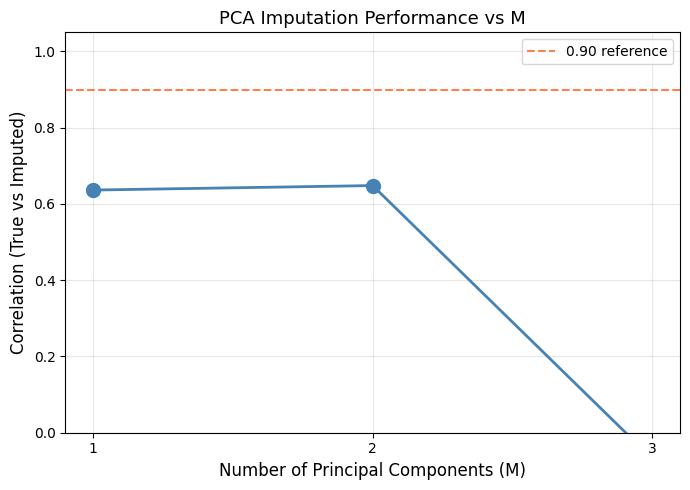


Best M = 2 with correlation = 0.6481


In [12]:
# Plot correlation vs M
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(list(correlations.keys()),
        list(correlations.values()),
        'o-', color='steelblue', linewidth=2, markersize=10)
ax.set_xlabel('Number of Principal Components (M)', fontsize=12)
ax.set_ylabel('Correlation (True vs Imputed)', fontsize=12)
ax.set_title('PCA Imputation Performance vs M', fontsize=13)
ax.set_xticks(M_values)
ax.set_ylim(0, 1.05)
ax.axhline(0.9, color='coral', linestyle='--',
           linewidth=1.5, label='0.90 reference')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_M = max(correlations, key=correlations.get)
print(f"\nBest M = {best_M} with correlation = {correlations[best_M]:.4f}")

The best result comes from M=2, but even that correlation of 0.65 is not strong enough to consider the imputed values reliable in the context of this project. There are two likely reasons for this.
- First, our dataset only has 86 rows after deduplication by job title, which gives PCA very little data to learn from.
- Second, salary and salary_in_usd are so strongly correlated that they do not provide independent information to help recover missing values, they essentially tell the same story twice, leaving work_year as the only truly different variable, which itself has no relationship with salary as we saw in the biplot.